In [8]:
import numpy as np
import matplotlib.pyplot as plt
import gzip
from pathlib import Path
import importlib.util
import bpmeth 
from math import factorial
import pyvista as pv
from pyvista.trame.jupyter import launch_server


In [6]:
ROOT = Path("/home/fmarcoli/bpmeth")

spec = importlib.util.spec_from_file_location("read", ROOT / "fieldmaps/hitriplus_cct/read.py")
read = importlib.util.module_from_spec(spec)
spec.loader.exec_module(read)
data = np.loadtxt(gzip.open(ROOT / "fieldmaps/hitriplus_cct/fieldmap-cct.txt.gz"), skiprows=9)

cctmagnet = read.Magnet(data)
# src = cctmagnet.src.copy()

# # --- swap coordinates y <-> z at the source level ---
# pts = src.points.copy()
# pts[:, [1, 2]] = pts[:, [2, 1]]
# src.points = pts

# # --- swap field components By <-> Bz if present ---
# if "By" in src.point_data and "Bz" in src.point_data:
#     by = src.point_data["By"].copy()
#     bz = src.point_data["Bz"].copy()
#     src.point_data["By"] = bz
#     src.point_data["Bz"] = by

# --- swap its y/z components too ---
# for name in ["B", "vectors", "magnetic_field"]:
#     if name in src.point_data:
#         vec = src.point_data[name].copy()
#         vec[:, [1, 2]] = vec[:, [2, 1]]
#         src.point_data[name] = vec

# Overview of magnet
cctmagnet.plot()

Bx = cctmagnet.data[:, 3]
By = cctmagnet.data[:, 5]#txt swithces y and z
Bz = cctmagnet.data[:, 4]

# Coordinates too:
x  = cctmagnet.data[:, 0]
y  = cctmagnet.data[:, 2]
z  = cctmagnet.data[:, 1]

originaldatafieldmap = np.column_stack([
    x, y, z, Bx, By, Bz
])
fm = bpmeth.fieldmaps.Fieldmap(originaldatafieldmap)
fm.plot('Bx')

Widget(value='<iframe src="http://localhost:36025/index.html?ui=P_0x7fcc2c3cef90_8&reconnect=auto" class="pyvi…

Widget(value='<iframe src="http://localhost:36025/index.html?ui=P_0x7fcce6d08710_9&reconnect=auto" class="pyvi…

In [ ]:
x = cctmagnet.data[:, 0]
y = cctmagnet.data[:, 2]
z = cctmagnet.data[:, 1]

Bx = cctmagnet.data[:, 3]
By = cctmagnet.data[:, 5]
Bz = cctmagnet.data[:, 4]

nx = len(np.unique(x))
ny = len(np.unique(y))
nz = len(np.unique(z))
print(nx, ny, nz)

shape = (ny, nz, nx)

X  = x.reshape(shape)
Y  = y.reshape(shape)
Z  = z.reshape(shape)

Bx3 = Bx.reshape(shape)
By3 = By.reshape(shape)
Bz3 = Bz.reshape(shape)

#1D axes
y_1d = Y[:, 0, 0]   # slowest
z_1d = Z[0, :, 0]   # middle
x_1d = X[0, 0, :]   # fastest


print("x monotonic:", np.all(np.diff(x_1d) > 0))
print("y monotonic:", np.all(np.diff(y_1d) > 0))
print("z monotonic:", np.all(np.diff(z_1d) > 0))
grid = pv.RectilinearGrid(x_1d, y_1d, z_1d)

Bx_xyz = Bx3.transpose(2, 0, 1)
By_xyz = By3.transpose(2, 0, 1)
Bz_xyz = Bz3.transpose(2, 0, 1)

grid.point_data["Bx"] = Bx_xyz.ravel(order="F")
grid.point_data["By"] = By_xyz.ravel(order="F")
grid.point_data["Bz"] = Bz_xyz.ravel(order="F")
# print(X[0, 0, 0], Y[0, 0, 0], Z[0, 0, 0])
# print(X[-1, -1, -1], Y[-1, -1, -1], Z[-1, -1, -1])
# print(grid.points[0])
# print(grid.points[-1])
pl = pv.Plotter()
pl.add_mesh(grid.extract_surface(), scalars="Bx", show_scalar_bar=True)
pl.show()


81 17 401
x monotonic: True
y monotonic: True
z monotonic: True
1.4 -0.04 -1.0
1.7999999999999998 0.04 1.0
[ 1.4  -0.04 -1.  ]
[1.8  0.04 1.  ]


/tmp/fmarcoli/ipykernel_41823/2766179005.py:47: PyVistaFutureWarning: The default value of `algorithm` for the filter
`RectilinearGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  pl.add_mesh(grid.extract_surface(), scalars="Bx", show_scalar_bar=True)


Widget(value='<iframe src="http://localhost:36025/index.html?ui=P_0x7fcc2c3ce4e0_10&reconnect=auto" class="pyv…

Sample and interpolate on cylindrical grid (to to HA)

In [13]:
def field_to_bent_cylindrical(
    magnet,
    rho=1.65,
    rmin=0.001,
    rmax=0.101,
    nr=128,
    ntheta=128,
    smin=None,
    smax=None,
    ns=50,
    radius=0.01,
    theta_endpoint=False,
):
    """
    Sample a Cartesian field on a bent cylindrical frame.

    Geometry:
        x = (rho + r*cos(theta)) * cos(phi)
        y = r*sin(theta)
        z = (rho + r*cos(theta)) * sin(phi)

    with phi = s / rho.

    Parameters
    ----------
    magnet : object
        Must provide magnet.src as a PyVista dataset with point_data.
    rho : float
        Bending radius [m].
    rmin, rmax : float
        Minor radius range [m].
    nr : int
        Number of radial points.
    ntheta : int
        Number of poloidal-angle points.
    smin, smax : float
        Arc-length range along reference orbit [m].
    ns : int
        Number of longitudinal points.
    radius : float
        Interpolation radius passed to PyVista interpolate().
    theta_endpoint : bool
        Whether theta includes endpoint 2*pi.

    Returns
    -------
    r_1d, theta_1d, s_1d : 1D arrays
    X, Y, Z : 3D arrays of shape (nr, ntheta, ns)
    Bx_rts, By_rts, Bz_rts : sampled field arrays, same shape
    dst : PyVista StructuredGrid with interpolated fields
    """
    if smin is None:
        smin = 0.0
    if smax is None:
        raise ValueError("smax must be provided")

    r_1d = np.linspace(rmin, rmax, nr)
    theta_1d = np.linspace(0.0, 2.0*np.pi, ntheta, endpoint=theta_endpoint)
    s_1d = np.linspace(smin, smax, ns)

    R, TH, S = np.meshgrid(r_1d, theta_1d, s_1d, indexing="ij")
    PHI = S / rho

    X = (rho + R*np.cos(TH)) * np.cos(PHI)
    Y = R*np.sin(TH)
    Z = (rho + R*np.cos(TH)) * np.sin(PHI)

    dst = pv.StructuredGrid(X, Y, Z)

    # Interpolate point data from the source field
    dst = dst.interpolate(
        magnet.src,
        radius=radius,
        sharpness=2.0,
        strategy="null_value",
        null_value=np.nan,
    )

    shape = X.shape
    Bx_rts = dst.point_data["Bx"].reshape(shape, order="F") if "Bx" in dst.point_data else None
    By_rts = dst.point_data["By"].reshape(shape, order="F") if "By" in dst.point_data else None
    Bz_rts = dst.point_data["Bz"].reshape(shape, order="F") if "Bz" in dst.point_data else None

    return r_1d, theta_1d, s_1d, X, Y, Z, Bx_rts, By_rts, Bz_rts, dst

Definitions for HA

In [11]:
def dkongrid(Byibx_rts, rr, nk, s_index):
    """
    Takes a precomputed field array and computes d_k as a function of r 
    Parameters
    ----------
    Byibx_rts : complex array, shape (nr, ntheta, ns) representing (By + i*Bx) already evaluated on the (r, theta, s) grid.
    Theta samples must be uniform in [0, 2*pi).
    rr     : array of r values, shape (nr,)
    nk     : max |k|
    s_index: index along the s-axis to use

    Returns
    -------
    out : complex array, shape (nr, 2*nk+1)  — same as dkharmonics
    """
    ntheta = Byibx_rts.shape[1]

    b = Byibx_rts[:, :, s_index]        # (nr, ntheta) at specified s
    d = np.fft.fft(b, axis=1) / ntheta       # FFT along theta axis

    out = np.empty((len(rr), 2*nk+1), dtype=complex)
    out[:, 0]    = d[:, 0]
    out[:, 1::2] = d[:, 1 : nk+1]
    out[:, 2::2] = d[:, ntheta : ntheta-nk-1 : -1]

    return out
def dklfitraw_nodiv_cheb(dkofrarray, rr, nk, nl):
    '''
    Numerically stable version of dklfitraw_nodiv.
    Fits dk(r) = sum_l d_kl * r^(|k|+2l) directly (no division by r^k),
    using rn = rr/rr.max() to keep basis values in (0,1].
    
    The d_kl returned are in the original (unnormalized) r basis, i.e. the r0 scaling is absorbed back into the coefficients.
    '''
    r0 = rr.max()
    rn = rr / r0    # in (0, 1]
    dkl_norm = np.zeros((2*nk+1, nl), dtype=complex)

    # k=0: basis is rn^0, rn^2, rn^4, ...
    V0 = np.column_stack([rn**(2*l) for l in range(nl)])
    dkl_norm[0, :] = np.linalg.lstsq(V0, dkofrarray[:, 0], rcond=None)[0]

    for ik, k in enumerate(np.arange(1, nk+1)):
        V = np.column_stack([rn**(k + 2*l) for l in range(nl)])
        dkl_norm[2*ik+1, :] = np.linalg.lstsq(V, dkofrarray[:, 2*ik+1], rcond=None)[0]
        dkl_norm[2*ik+2, :] = np.linalg.lstsq(V, dkofrarray[:, 2*ik+2], rcond=None)[0]
    # Rescale: since rn = r/r0, rn^(k+2l) = r^(k+2l) / r0^(k+2l)
    # so d_kl_norm = d_kl * r0^(k+2l) → d_kl = d_kl_norm / r0^(k+2l)
    dkl = np.zeros((2*nk+1, nl), dtype=complex)
    dkl[0, :] = dkl_norm[0, :] / r0**(2*np.arange(nl))

    for ik, k in enumerate(np.arange(1, nk+1)):
        scale = r0**(k + 2*np.arange(nl))
        dkl[2*ik+1, :] = dkl_norm[2*ik+1, :] / scale
        dkl[2*ik+2, :] = dkl_norm[2*ik+2, :] / scale

    return dkl
#now let's recover the a,b coefficients
def bnianHAopt(dkl, nl, nk):#from dkl to bn and an
    # Precompute factorials
    fact = np.array([factorial(n) for n in range(nk)], dtype=np.int16)

    # Build k index dict mapping: row index for k = 0,1,-1,2,-2,...
    k_index = {0: 0}
    for i in range(1, nk+1):
        k_index[i]  = 2*i - 1
        k_index[-i] = 2*i #negative k gets even row

    result = np.zeros(nk, dtype=np.complex128)

    for n in range(nk):
        s = 0.0 + 0.0j #initialize sum
        max_l = min(n//2, nl-1)

        for l in range(max_l + 1):#
            k = n - 2*l
            if k == 0:
                s += dkl[k_index[0], l]
            else:
                s += dkl[k_index[k], l] + dkl[k_index[-k], l]

        result[n] = fact[n] * s

    return result
def LHongrid_nodiv_cheb(ByiBxongrid, s_index, nk):
    '''
    local harmonic analysis from By+iBx to dkl and coefficients a,b 
    '''
    dk=dkongrid(Byibx_rts=ByiBxongrid, rr=rr, nk=nk, s_index=s_index)
    dkl=dklfitraw_nodiv_cheb(dkofrarray=dk,rr=rr,nk=nk, nl=nl)
    an=bnianHAopt(dkl, nl,nk).imag
    bn=bnianHAopt(dkl, nl,nk).real
    return an, bn

In [14]:
nk=4
nl=nk//2+1
rho = 1.65
rmin=x_1d[0]
rmax=x_1d[nx-1]
print(z_1d[-1]-z_1d[0])
thetahalf = np.asin((z_1d[-1]-z_1d[0])/(2*rho))
smax=rho*thetahalf
print(f"Calculated smax: {smax:.3f} m")
print("thetahalf (degrees):", np.degrees(thetahalf))

r_1d, theta_1d, s_1d, X, Y, Z, Bx_rts, By_rts, Bz_rts, dst = field_to_bent_cylindrical(
    magnet=cctmagnet,
    rho=1.65,
    rmin=0.001,
    rmax=0.039,
    nr=128,
    ntheta=128,
    smin=-smax,
    smax=smax,
    ns=40,
    radius=0.01,
)

ByiBx_rts = By_rts + 1j*Bx_rts
dk = dkongrid(Byibx_rts=ByiBx_rts, rr=r_1d, nk=nk, s_index=s_1d.size // 2)
dkl = dklfitraw_nodiv_cheb(dkofrarray=dk, rr=r_1d, nk=nk, nl=nl)
print(dkl)
an, bn = bnianHAopt(dkl, nl, nk).imag, bnianHAopt(dkl, nl, nk).real
print("an:", an)
print("bn:", bn)

2.0
Calculated smax: 1.074 m
thetahalf (degrees): 37.305200965785076
[[ 8.77509230e-04-6.68206710e-05j -1.39356560e+01-1.38171711e+00j
   1.57373975e+04+1.61123692e+03j]
 [ 1.16100825e-02+1.00196385e-01j -5.18081347e+01-6.00962778e+02j
   4.80600364e+04+5.23504919e+05j]
 [ 1.08180698e-02+1.03562019e-01j -5.28425147e+01-5.97352173e+02j
   4.88011849e+04+5.21615442e+05j]
 [ 7.64495774e+00+5.35709767e-01j -2.61399567e+04-1.92668418e+03j
   1.94189696e+07+1.57263891e+06j]
 [ 7.60756939e+00+5.31524754e-01j -2.61219028e+04-1.98833261e+03j
   1.93910633e+07+1.62859693e+06j]
 [ 4.43536936e+00+1.87441703e+02j -2.19370534e+04-5.68401972e+05j
   2.10662638e+07+4.01519626e+08j]
 [ 7.94778965e+00+1.82248702e+02j -2.88174100e+04-5.53656284e+05j
   2.50925805e+07+3.93323231e+08j]
 [ 4.76103390e+03-5.35615710e+01j -1.41199003e+07-1.39756079e+05j
   9.90425824e+09+3.29976034e+08j]
 [ 4.93697210e+03+1.49260140e+01j -1.43842817e+07-2.69117008e+05j
   9.99936066e+09+3.91532982e+08j]]
an: [-6.68206710e-05 

X range: 1.281419154526253 1.6887646285104938
Y range: -0.039 0.039
Z range: -1.0236363636363635 1.0236363636363635
shape: (128, 128, 40)
Sample X: 1.281419154526253 1.6887646285104938
Sample Y: -0.039 0.039
Sample Z: -1.0236363636363635 1.0236363636363635

Source X: 1.4 1.7999999999999998
Source Y: -0.04 0.04
Source Z: -1.0 1.0
Bx finite fraction: 0.8


/tmp/fmarcoli/ipykernel_8838/4088657271.py:79: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  pl.show()


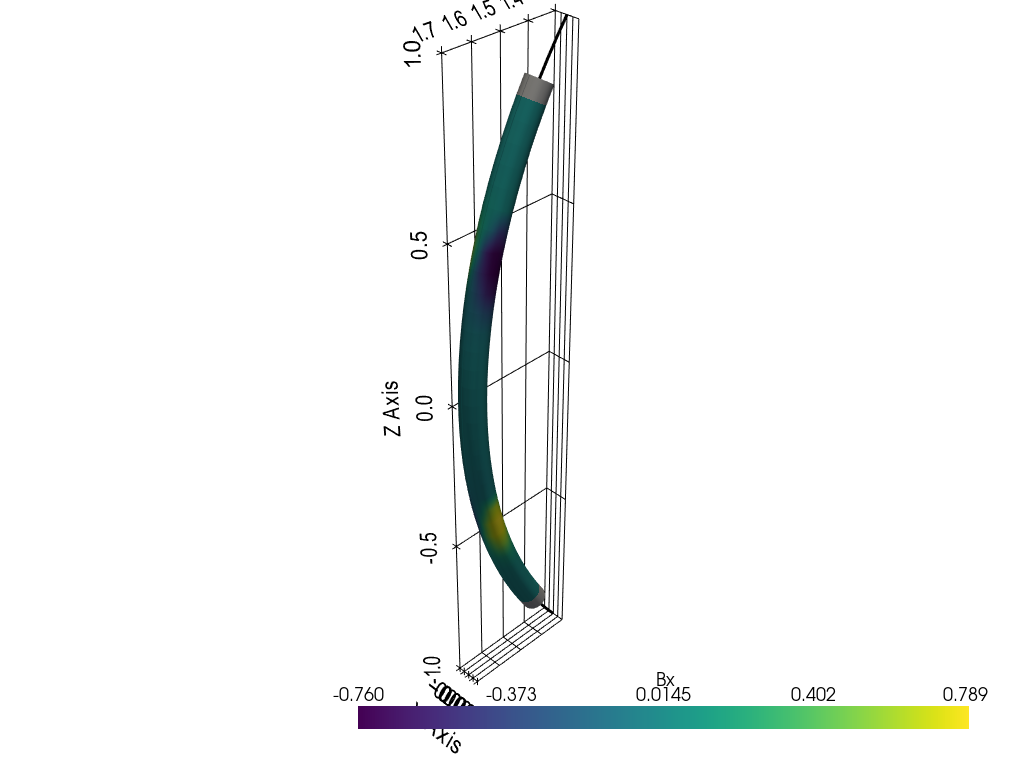

In [ ]:
def plot_bent_sampling_Bx(
    magnet,
    rho=1.65,
    rmin=0.001,
    rmax=0.039,
    nr=128,
    ntheta=128,
    smin=-smax,
    smax=smax,
    ns=40,
    radius=0.01,
):
    # bent cylindrical coordinates
    r_1d = np.linspace(rmin, rmax, nr)
    theta_1d = np.linspace(0.0, 2.0*np.pi, ntheta, endpoint=False)
    s_1d = np.linspace(smin, smax, ns)

   
    R, TH, S = np.meshgrid(r_1d, theta_1d, s_1d, indexing="ij")
    PHI = S / rho

    X = (rho + R*np.cos(TH)) * np.cos(PHI)
    Y = R*np.sin(TH)
    Z = (rho + R*np.cos(TH)) * np.sin(PHI)
   
    print("X range:", X.min(), X.max())
    print("Y range:", Y.min(), Y.max())
    print("Z range:", Z.min(), Z.max())
    print("shape:", X.shape)
    # Where are the sample points?
    print("Sample X:", X.min(), X.max())
    print("Sample Y:", Y.min(), Y.max())
    print("Sample Z:", Z.min(), Z.max())
    # Where is the source data?
    print("\nSource X:", cctmagnet.src.bounds[0], cctmagnet.src.bounds[1])
    print("Source Y:", cctmagnet.src.bounds[2], cctmagnet.src.bounds[3])
    print("Source Z:", cctmagnet.src.bounds[4], cctmagnet.src.bounds[5])
        # curved sampling grid
    dst = pv.StructuredGrid(X, Y, Z)

    # interpolate field from source cloud/grid
    dst = dst.interpolate(
        magnet.src,
        radius=radius,
        sharpness=2.0,
        strategy="null_value",
        null_value=np.nan,
    )

    # optional: inspect how much of the grid was actually sampled
    bx = dst.point_data["Bx"]
    print("Bx finite fraction:", np.isfinite(bx).sum() / bx.size)

    # plot
    pl = pv.Plotter()

    # show only points/cells with valid Bx
    valid = dst.threshold(
        value=[np.nanmin(bx), np.nanmax(bx)],
        scalars="Bx"
    )

    pl.add_mesh(
        valid,
        scalars="Bx",
        show_scalar_bar=True,
        scalar_bar_args={"title": "Bx"},
    )

    # optional reference orbit (r = 0)
    phi_1d = s_1d / rho
    x_ref = rho * np.cos(phi_1d)
    y_ref = np.zeros_like(phi_1d)
    z_ref = rho * np.sin(phi_1d)
    ref = pv.lines_from_points(np.column_stack([x_ref, y_ref, z_ref]))
    pl.add_mesh(ref, color="black", line_width=3)

    pl.show_grid()
    pl.show()

    return dst

src = cctmagnet.src.copy()

# --- swap coordinates y <-> z at the source level ---
pts = src.points.copy()
pts[:, [1, 2]] = pts[:, [2, 1]]
src.points = pts

# --- swap field components By <-> Bz if present ---
if "By" in src.point_data and "Bz" in src.point_data:
    by = src.point_data["By"].copy()
    bz = src.point_data["Bz"].copy()
    src.point_data["By"] = bz
    src.point_data["Bz"] = by

# --- if a vector field also exists, swap its y/z components too ---
for name in ["B", "vectors", "magnetic_field"]:
    if name in src.point_data:
        vec = src.point_data[name].copy()
        vec[:, [1, 2]] = vec[:, [2, 1]]
        src.point_data[name] = vec

# replace the original source with the corrected one
cctmagnet.src = src
dst = plot_bent_sampling_Bx(
    magnet=cctmagnet,
    rho=1.65,
    rmin=0.001,
    rmax=0.039,
    nr=128,
    ntheta=128,
    smin=-smax,
    smax=smax,
    ns=40,
    radius=0.01,
)
